<a href="https://colab.research.google.com/github/oceofa/hw1/blob/main1/cifar100.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from keras.datasets import cifar100
from keras.datasets import cifar100
(x_train, y_train),(x_test, y_test)=cifar100.load_data()
x_train.shape
x_test.shape
x_train = x_train.reshape(50000, 32*32*3)
x_train= x_train.astype('float32')/255
x_test = x_test.reshape(10000, 32*32*3)
x_test= x_test.astype('float32')/255
x_test = x_test.reshape(10000, 32*32*3)
x_test= x_test.astype('float32')/255
from keras.utils import to_categorical
# The CIFAR-100 dataset has 100 classes, not 10.
# Changing num_classes to 100 to reflect the correct number of classes
y_train = to_categorical(y_train, num_classes=100)
y_test = to_categorical(y_test, num_classes=100)

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [ ]:
from keras.models import Sequential
from keras.layers import Dense
model = Sequential()
model.add(Dense(512, input_shape=(32*32*3,), activation='relu'))
model.add(Dense(112, input_shape=(32*32*3,), activation='relu'))
model.add(Dense(100, input_shape=(32*32*3,), activation='softmax'))
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 512)                 │       1,573,376 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 112)                 │          57,456 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 100)                 │          11,300 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,642,132 (6.26 MB)

 Trainable params: 1,642,132 (6.26 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(x_train, y_train, batch_size=64, epochs=500, validation_data=(x_test, y_test))

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
model.save("/content/drive/MyDrive/4.h5")

In [ ]:
from keras.models import load_model
model = load_model("/content/drive/MyDrive/4.h5")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


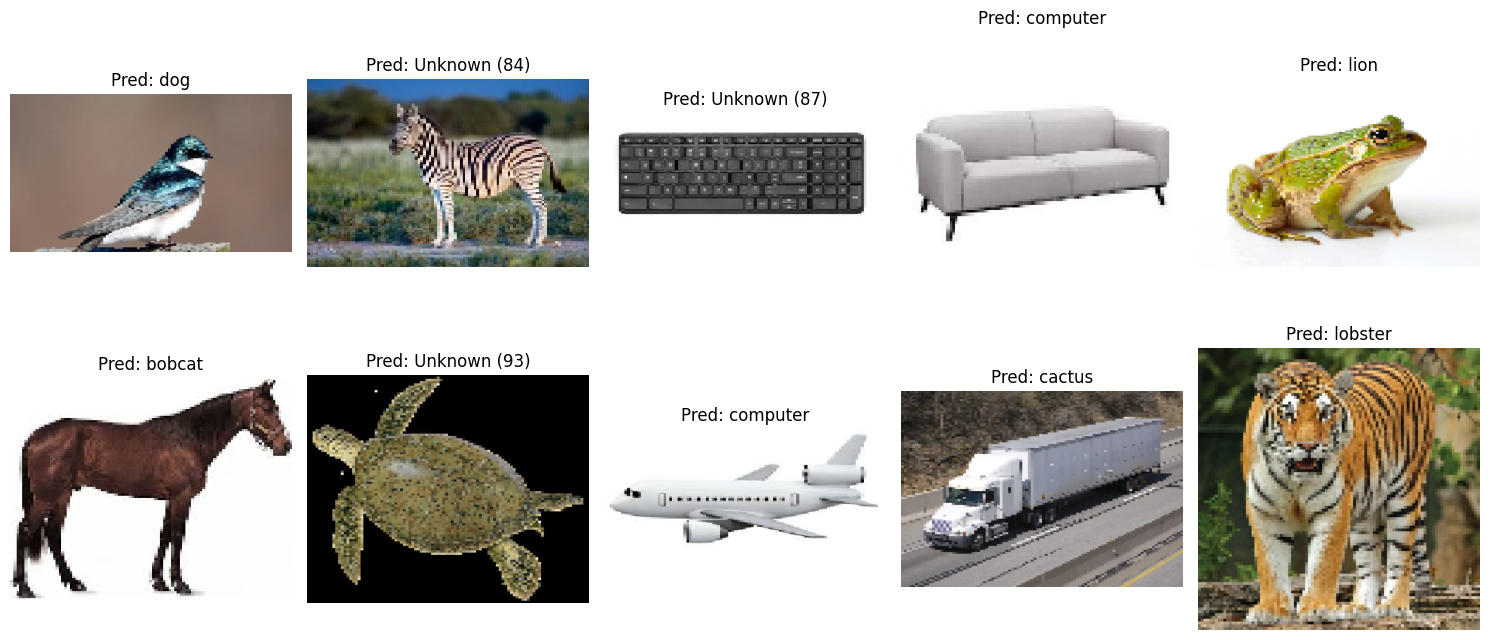

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from keras.models import load_model

class_names = [
    'apple', 'aquarium_fish', 'baby', 'bicycle', 'big_cat', 'black-footed_ferret',
    'blue', 'bobcat', 'bookshelf', 'bowl', 'bride', 'cactus', 'cake', 'carrot',
    'cat', 'cattle', 'chair', 'clock', 'cloud', 'cocktail', 'computer', 'cushion',
    'deer', 'dog', 'domestic_cat', 'dragonfly', 'elephant', 'fish', 'fox',
    'frog', 'giant_panda', 'giraffe', 'goat', 'goldfish', 'grasshopper',
    'hamster', 'house', 'kangaroo', 'keyboard', 'koala', 'leopard', 'lion',
    'lobster', 'manatee', 'mouse', 'orange', 'otter', 'palm_tree',
    'penguin', 'quilt', 'rabbit', 'raccoon', 'rainbow', 'sea', 'sheep',
    'skateboard', 'sofa', 'squirrel', 'starfish', 'strawberry', 'sunflower',
    'table', 'tea', 'tiger', 'toothbrush', 'turtle', 'walrus', 'whale',
    'zebra'
]

def preprocess_image(image_path):
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"Image not found at path: {image_path}")

    img = cv2.resize(img, (32, 32))
    img = img.astype("float32") / 255.0
    img = img.reshape(1, 32*32*3)
    return img

def pixelate_image(img, pixel_size=8):
    """
    Giảm độ phân giải ảnh xuống 'pixel_size' và sau đó phóng to lại để tạo hiệu ứng pixel hóa.
    """
    height, width = img.shape[:2]
    temp = cv2.resize(img, (pixel_size, pixel_size), interpolation=cv2.INTER_LINEAR)
    pixelated = cv2.resize(temp, (width, height), interpolation=cv2.INTER_NEAREST)
    return pixelated

def predict_animal(image_path):
    processed_img = preprocess_image(image_path)
    prediction = model.predict(processed_img)
    predicted_class = np.argmax(prediction)
    return predicted_class

image_paths = [
    "/content/bird.webp",
    "/content/zebra.jpg",
    "/content/keyboard.jpg",
    "/content/sofa.jpg",
    "/content/frog.jpg",
    "/content/hourse.jpg",
    "/content/turtle.png",
    "/content/plane.jpg",
    "/content/truck.webp",
    "/content/tiger.webp"
]

predicted_results = {}
fig, axes = plt.subplots(2, 5, figsize=(15, 7))

for i, image_path in enumerate(image_paths):
    try:
        predicted_class = predict_animal(image_path)
        predicted_results[image_path] = predicted_class
        if 0 <= predicted_class < len(class_names):
            predicted_label = class_names[predicted_class]
        else:
            predicted_label = f"Unknown ({predicted_class})"

        img = cv2.imread(image_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = pixelate_image(img, pixel_size=100)

        ax = axes[i // 5, i % 5]
        ax.imshow(img)
        ax.set_title(f"Pred: {predicted_label}")
        ax.axis('off')

    except FileNotFoundError as e:
        print(e)

plt.tight_layout()
plt.show()

